# PLS_Regression — previsões e resíduos

Lê as previsões finais e salva os gráficos de diagnóstico.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Image

here = Path.cwd().resolve()
group = next(
    (p for p in [here, *here.parents] if (p / "config.py").exists() and (p / "lib").is_dir()),
    None,
)
if group is None:
    raise RuntimeError("Não encontrei analyses/grupo2. Abra o notebook dentro do projeto.")
if str(group) not in sys.path:
    sys.path.insert(0, str(group))

import config
from lib import data as data_lib, features, eda_stl
from lib import models_v2 as models
from lib.nb_boot import require_file, save_json, load_json
data_lib.ensure_output_dirs()
print("outputs →", config.OUTPUT_DIR)


outputs → C:\Users\brunacardoso-ieg\OneDrive - Instituto Germinare\Área de Trabalho\Tech\Séries Temporais\trabalho_PLS_grupo2\pls-regration-comparation\analyses\grupo2\outputs


MAE oficial = 191.6959713618109
Diagnóstico horário: n = 168 | viés = -23.984250479095305


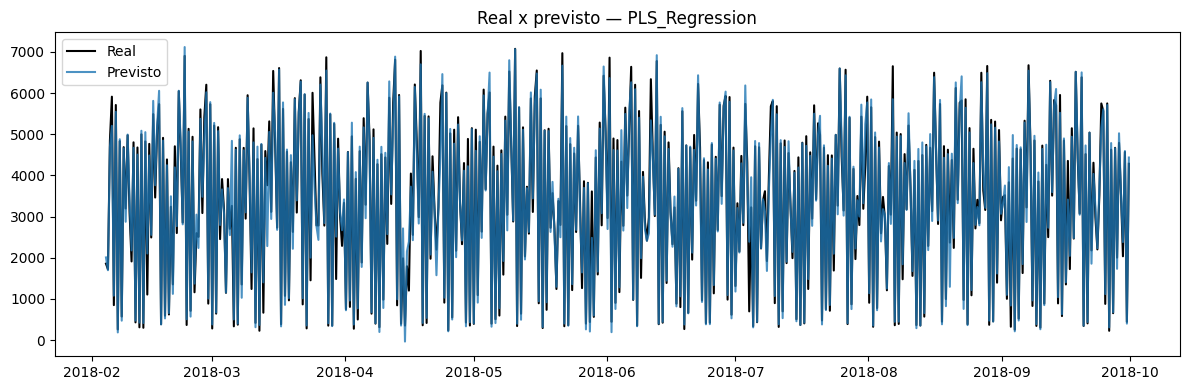

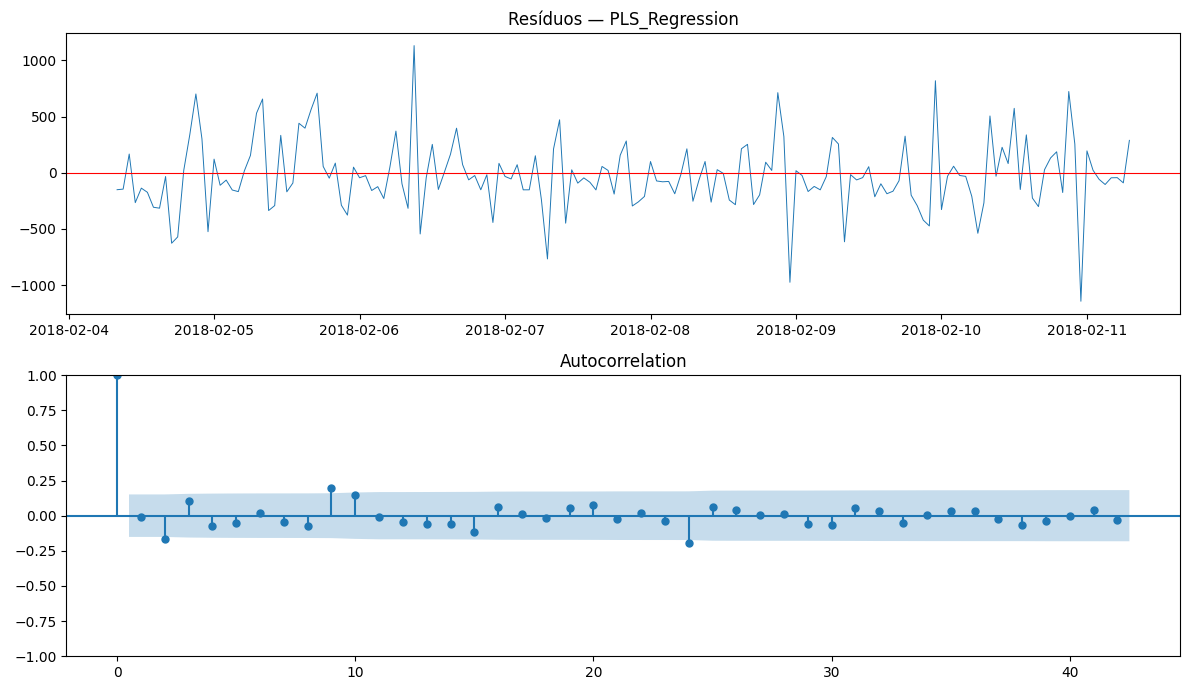

In [2]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

path = require_file(
    config.RESULT_DIR / "predictions_PLS_Regression.csv",
    "02_walkforward_validacao.ipynb",
)
pred = pd.read_csv(path, parse_dates=["forecast_origin", "target_date"])
diag_path = require_file(
    config.RESULT_DIR / "residual_diagnostic_PLS_Regression.csv",
    "02_walkforward_validacao.ipynb",
)
diag = pd.read_csv(diag_path, parse_dates=["forecast_origin", "target_date"])
residual = diag["residual"]
print("MAE oficial =", pred["residual"].abs().mean())
print("Diagnóstico horário: n =", len(diag), "| viés =", residual.mean())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pred["target_date"], pred["y_true"], label="Real", color="black")
ax.plot(pred["target_date"], pred["y_pred"], label="Previsto", alpha=.8)
ax.set_title("Real x previsto — PLS_Regression")
ax.legend(); fig.tight_layout()
fig.savefig(config.FIG_DIR / "previsao_PLS_Regression.png", dpi=140)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
axes[0].plot(diag["target_date"], residual, lw=.7)
axes[0].axhline(0, color="red", lw=.8)
axes[0].set_title("Resíduos — PLS_Regression")
plot_acf(residual, lags=min(72, len(residual)//4), ax=axes[1])
fig.tight_layout()
fig.savefig(config.FIG_DIR / "residuos_PLS_Regression.png", dpi=140)
plt.show()
